In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import scipy
from sklearn.preprocessing import StandardScaler
from scipy import signal
from scipy import fft
from scipy.fft import fft, ifft, fftfreq
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import os
import time

# Setup environment - works for both Colab and local
try:
    import google.colab
    IN_COLAB = True
    # Clone repo if not present
    if not os.path.exists('/content/BCI'):
        !git clone https://github.com/sorinnicumarian/BCI.git /content/BCI
    os.chdir('/content/BCI/notebook')
except:
    IN_COLAB = False

print(f"Running in {'Colab' if IN_COLAB else 'Local'}")
print(f"Current directory: {os.getcwd()}")

Running in Local
Current directory: /Users/sorin/Documents/Repos/BCI/notebook


In [ ]:
# DATASET 05 - 4-CLASS VISUAL FOCUS (Mouse Control)
# Collected Feb 17-18, 2025
# 
# All states with EYES OPEN - using visual targets instead of motor imagery
# Class 0: RELAX - pulse relax, imagine mouse going DOWN
# Class 1: FOCUS - pulse focus, imagine mouse going UP
# Class 2: LEFT - watch FOOTBALL, pulse attention, pulse left fist
# Class 3: RIGHT - watch STAR, sustained attention, clench right fist

df0 = pd.read_csv('../artefacts/data/05_relax.csv')
df0 = df0.iloc[100:-100].reset_index(drop=True)  # Drop only first/last 100 samples
df0['label'] = 0      # relax state (down)

In [ ]:
df1 = pd.read_csv('../artefacts/data/05_concentrate.csv')
df1 = df1.iloc[100:-100].reset_index(drop=True)  # Drop only first/last 100 samples
df1['label'] = 1      # focus/concentrate state 

df2 = pd.read_csv('../artefacts/data/05_left_fist_pulse.csv')
df2 = df2.iloc[100:-100].reset_index(drop=True)  # Drop only first/last 100 samples
df2['label'] = 2      # left 

df3 = pd.read_csv('../artefacts/data/05_right_fist_clench.csv')
df3 = df3.iloc[100:-100].reset_index(drop=True)  # Drop only first/last 100 samples
df3['label'] = 3      # right 

df = pd.concat([df0, df1, df2, df3], ignore_index=True)
df.isnull().sum()
df.drop(columns=df.columns[0], inplace=True)
df.columns = ['raw_eeg', 'label']
print(f"Training on 4-Class Mouse Control (Session 5)")
print(f"Total raw samples: {len(df)}")
print(f"Class distribution:")
print(df['label'].value_counts().sort_index())
print(f"\nFirst samples (relax/down):")
print(df.head())
print(f"\nLast samples (right):")
print(df.tail())

In [ ]:
data = df['raw_eeg']
labels_old = df['label']

sampling_rate = 512

notch_freq = 50.0  # for the notch filter
lowcut, highcut = 0.5, 30.0  # for the bandpass filter

#  notch filter
nyquist = (0.5 * sampling_rate)

#Improvement 1 - Correct 50 Hz notch in Hz, with a narrow Q
b_notch, a_notch = signal.iirnotch(w0=50.0, Q=30.0, fs=sampling_rate)

#Improvement 2
# stable 0.5–30 Hz band-pass as SOS
sos_bp = signal.butter(4, [0.5, 30.0], btype='band', fs=sampling_rate, output='sos')


features = []
labels = []
additional_features_list = []

# Exponential smoothing state (like Arduino code)
SMOOTHING_FACTOR = 0.63
smoothed_alpha = 0
smoothed_beta = 0
smoothed_theta = 0
smoothed_delta = 0

#Improvement 5 - Absolute power depends on electrode position, skin contact, amplifier gain, etc.
def calculate_psd_features(segment, sampling_rate):
    f, psd_values = scipy.signal.welch(segment, fs=sampling_rate, nperseg=len(segment))

    # Total energy in passband (0.5–30 Hz)
    total = psd_values[(f >= 0.5) & (f <= 30.0)].sum() + 1e-12

    E_alpha = psd_values[(f >= 8)  & (f <= 13)].sum() / total
    E_beta  = psd_values[(f >= 13) & (f <= 30)].sum() / total
    E_theta = psd_values[(f >= 4)  & (f <= 7)].sum()  / total
    E_delta = psd_values[(f >= 0.5)& (f <= 3)].sum()  / total

    alpha_beta_ratio = (E_alpha + 1e-12) / (E_beta + 1e-12)
    
    # NEW: Additional frequency ratios
    theta_alpha_ratio = (E_theta + 1e-12) / (E_alpha + 1e-12)
    beta_theta_ratio = (E_beta + 1e-12) / (E_theta + 1e-12)
    engagement_index = E_beta / (E_alpha + E_theta + 1e-12)
    
    # NEW: Beta percentage (like Arduino - most discriminative!)
    beta_percentage = E_beta * 100  # Already relative, convert to %

    return {
        'E_alpha': E_alpha,
        'E_beta': E_beta,
        'E_theta': E_theta,
        'E_delta': E_delta,
        'alpha_beta_ratio': alpha_beta_ratio,
        'theta_alpha_ratio': theta_alpha_ratio,
        'beta_theta_ratio': beta_theta_ratio,
        'engagement_index': engagement_index,
        'beta_percentage': beta_percentage
    }


#Improvement 6 - Spectral slope in 2–30 Hz, peak inside 0.5–30 Hz
def calculate_additional_features(segment, sampling_rate):
    f, psd = scipy.signal.welch(segment, fs=sampling_rate, nperseg=len(segment))

    # Peak frequency inside 0.5–30 Hz (avoid DC = 0 Hz)
    idx_pb = (f >= 0.5) & (f <= 30.0)
    peak_frequency = float(f[idx_pb][np.argmax(psd[idx_pb])])

    # Spectral slope in 2–30 Hz (log10 for stability)
    idx_slope = (f >= 2.0) & (f <= 30.0)
    logf = np.log10(f[idx_slope] + 1e-12)
    logp = np.log10(psd[idx_slope] + 1e-12)
    spectral_slope = float(np.polyfit(logf, logp, 1)[0])

    # Centroid in passband
    spectral_centroid = float((f[idx_pb] * psd[idx_pb]).sum() / (psd[idx_pb].sum() + 1e-12))

    return {
        'peak_frequency': peak_frequency,
        'spectral_centroid': spectral_centroid,
        'spectral_slope': spectral_slope
    }


# NEW: Temporal features - capture signal dynamics
def calculate_temporal_features(segment):
    """Time-domain features capturing signal dynamics"""
    segment = np.array(segment)
    
    # Hjorth mobility (mean frequency indicator)
    diff_segment = np.diff(segment)
    hjorth_mobility = np.std(diff_segment) / (np.std(segment) + 1e-12)

    # Hjorth complexity (change in frequency)
    diff2_segment = np.diff(diff_segment)
    mobility2 = np.std(diff2_segment) / (np.std(diff_segment) + 1e-12)
    hjorth_complexity = mobility2 / (hjorth_mobility + 1e-12)

    # Zero-crossing rate (rough frequency estimate)
    zero_crossings = np.sum(np.diff(np.sign(segment)) != 0) / len(segment)

    # Signal variance (overall power)
    variance = np.var(segment)

    return {
        'hjorth_mobility': hjorth_mobility,
        'hjorth_complexity': hjorth_complexity,
        'zero_crossing_rate': zero_crossings,
        'signal_variance': variance
    }

# BETTER TRAINING: Use 50% overlap (256) for 2x more training samples
# 512 = no overlap (fast, ~525 samples), 256 = 50% overlap (1 min, ~1050 samples)
STEP_SIZE = 256  # 50% overlap for better model accuracy

print(f"Extracting features with step size {STEP_SIZE} (window size: 512)...")
start_time = time.time()

for i in range(0, len(data) - 512, STEP_SIZE):
    #Improvement 3 - .iloc for exact 512 samples
    segment = data.iloc[i:i+512]
    segment = pd.to_numeric(segment, errors='coerce')

    #Improvement 4 - Artifact rejection
    segment = segment.astype(float)
    z = (segment - segment.mean()) / (segment.std() + 1e-9)
    if np.max(np.abs(z)) > 6 or segment.std() < 1e-3:
      continue

    #  notch filter
    segment = signal.filtfilt(b_notch, a_notch, segment)

    #  bandpass filter (SOS format)
    segment = signal.sosfiltfilt(sos_bp, segment)

    # Extract all features
    segment_features = calculate_psd_features(segment, 512)
    additional_features = calculate_additional_features(segment, 512)
    temporal_features = calculate_temporal_features(segment)

    # NEW: Exponential smoothing (like Arduino!)
    smoothed_alpha = SMOOTHING_FACTOR * segment_features['E_alpha'] + (1 - SMOOTHING_FACTOR) * smoothed_alpha
    smoothed_beta = SMOOTHING_FACTOR * segment_features['E_beta'] + (1 - SMOOTHING_FACTOR) * smoothed_beta
    smoothed_theta = SMOOTHING_FACTOR * segment_features['E_theta'] + (1 - SMOOTHING_FACTOR) * smoothed_theta
    smoothed_delta = SMOOTHING_FACTOR * segment_features['E_delta'] + (1 - SMOOTHING_FACTOR) * smoothed_delta
    
    # Add smoothed features
    segment_features['smoothed_beta'] = smoothed_beta
    segment_features['smoothed_alpha'] = smoothed_alpha
    segment_features['smoothed_ratio'] = (smoothed_alpha + 1e-12) / (smoothed_beta + 1e-12)

    segment_features = {**segment_features, **additional_features, **temporal_features}

    features.append(segment_features)
    labels.append(labels_old.iloc[i])

X = np.array(features)
y = np.array(labels)

elapsed = time.time() - start_time
print(f"Feature extraction complete! Generated {len(features)} samples in {elapsed:.1f}s")

In [38]:
#features
segment_features

{'E_alpha': np.float64(0.30259992829322163),
 'E_beta': np.float64(0.45414274559701867),
 'E_theta': np.float64(0.1656855303668776),
 'E_delta': np.float64(0.10625830502651717),
 'alpha_beta_ratio': np.float64(0.666310166191812),
 'theta_alpha_ratio': np.float64(0.547539886416561),
 'beta_theta_ratio': np.float64(2.7409921952126357),
 'engagement_index': np.float64(0.9697989489049761),
 'beta_percentage': np.float64(45.414274559701866),
 'smoothed_beta': np.float64(0.3195340250824902),
 'smoothed_alpha': np.float64(0.2751723271618185),
 'smoothed_ratio': np.float64(0.8611675300961125),
 'peak_frequency': 7.0,
 'spectral_centroid': 12.449926682141705,
 'spectral_slope': -0.802218248270524,
 'hjorth_mobility': np.float64(0.13155003869985288),
 'hjorth_complexity': np.float64(1.8168658182794648),
 'zero_crossing_rate': np.float64(0.029296875),
 'signal_variance': np.float64(30.940403519907033)}

In [39]:
columns = ['E_alpha', 'E_beta', 'E_theta', 'E_delta', 
           'alpha_beta_ratio', 'theta_alpha_ratio', 'beta_theta_ratio', 'engagement_index',
           'beta_percentage',
           'peak_frequency', 'spectral_centroid', 'spectral_slope',
           'hjorth_mobility', 'hjorth_complexity', 'zero_crossing_rate', 'signal_variance',
           'smoothed_beta', 'smoothed_alpha', 'smoothed_ratio']

# Create a DataFrame
df = pd.DataFrame(features, columns=columns)

df['label'] = y

print(f"Total features extracted: {len(df)}")
print(f"Feature count: {len(columns)}")
print("\nArduino-inspired features added:")
print("  - beta_percentage (like Arduino threshold)")
print("  - smoothed_beta, smoothed_alpha, smoothed_ratio (exponential smoothing)")

Total features extracted: 525
Feature count: 19

Arduino-inspired features added:
  - beta_percentage (like Arduino threshold)
  - smoothed_beta, smoothed_alpha, smoothed_ratio (exponential smoothing)


In [40]:
df.describe()

,E_alpha,E_beta,E_theta,E_delta,alpha_beta_ratio,theta_alpha_ratio,beta_theta_ratio,engagement_index,beta_percentage,peak_frequency,spectral_centroid,spectral_slope,hjorth_mobility,hjorth_complexity,zero_crossing_rate,signal_variance,smoothed_beta,smoothed_alpha,smoothed_ratio,label
count,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000,525.000000
mean,0.218002,0.182218,0.174040,0.443380,1.573889,1.468206,1.470145,0.494027,18.221840,2.714286,6.904419,-1.493557,0.103854,2.277416,0.026797,86.691078,0.181861,0.217695,1.331524,0.499048
std,0.135726,0.110631,0.107052,0.222963,1.457130,2.304886,1.509200,0.288312,11.063144,3.200412,2.559313,0.628558,0.027471,0.586334,0.010494,196.122340,0.081244,0.105066,0.728988,0.500476
min,0.004251,0.003778,0.016085,0.020068,0.185562,0.046579,0.007393,0.006653,0.377765,1.000000,1.450236,-4.722239,0.036269,1.356096,0.003906,12.368385,0.024405,0.024303,0.385266,0.000000
25%,0.112766,0.093564,0.095260,0.268449,0.764497,0.440123,0.648096,0.298366,9.356400,1.000000,4.906447,-1.766056,0.084840,1.822226,0.019531,25.695722,0.120425,0.137454,0.838028,0.000000
50%,0.196270,0.172314,0.153262,0.429928,1.169070,0.779366,1.124562,0.435899,17.231374,1.000000,6.813971,-1.407699,0.102867,2.190904,0.027344,41.541005,0.174743,0.202560,1.189789,0.000000
75%,0.302517,0.249699,0.228760,0.607188,1.864961,1.515700,1.764139,0.650607,24.969863,3.000000,8.792164,-1.108847,0.122929,2.629432,0.033203,65.065957,0.238873,0.283912,1.585249,1.000000
max,0.641163,0.626097,0.690987,0.968819,15.041816,25.991534,13.811989,2.115790,62.609741,19.000000,13.287531,0.057349,0.174360,5.603597,0.058594,2794.385711,0.496991,0.540682,5.889952,1.000000


In [41]:
df.to_csv('ready.csv')

In [42]:
scaler = StandardScaler()
#scaler = RobustScaler()
X_scaled = scaler.fit_transform(df.drop('label', axis=1))
df_scaled = pd.DataFrame(X_scaled, columns=columns)

# Add labels to the DataFrame
df_scaled['label'] = df['label']

In [43]:
#df_scaled
X_scaled

array([[-0.9397681 , -0.19781116,  0.08193127, ..., -0.99593793,
        -1.53034166, -1.05273078],
       [-0.10039077, -0.44051752, -1.25651249, ..., -0.74363326,
        -0.64608137, -0.1345408 ],
       [ 0.30018314,  1.24349365,  0.57360795, ...,  0.79439717,
         0.00709998, -0.61071803],
       ...,
       [-1.03852601, -1.37604152, -0.63408392, ..., -1.87430672,
        -1.17873548,  2.51170395],
       [ 0.65977346, -0.50928191,  1.4262266 , ..., -1.12762123,
         0.10266871,  1.6444204 ],
       [ 0.62389076,  2.46027435, -0.07811643, ...,  1.69617215,
         0.5475853 , -0.6458339 ]], shape=(525, 19))

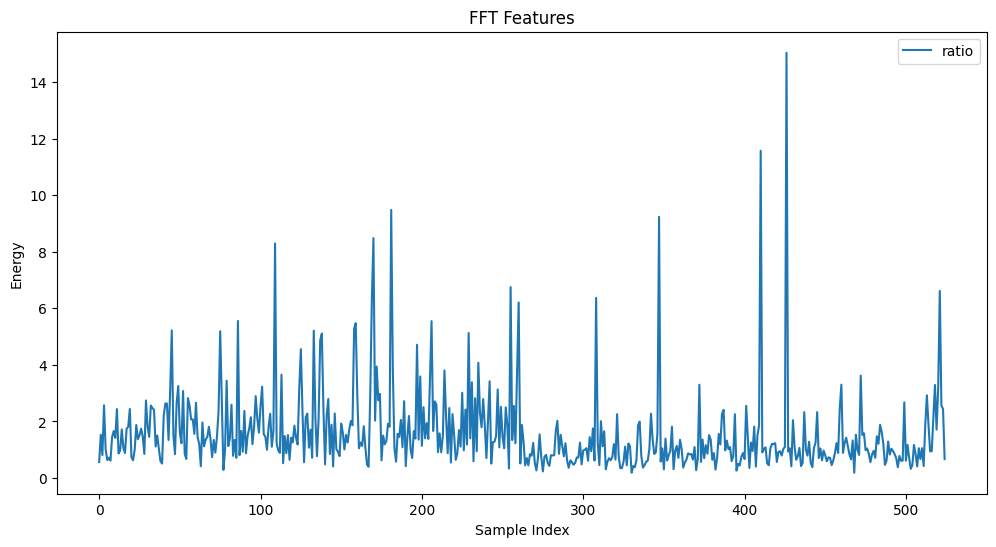

In [44]:
import matplotlib.pyplot as plt

# Plot FFT features
plt.figure(figsize=(12, 6))
#plt.plot(df.index, df['E_alpha'], label='Alpha Energy')
#plt.plot(df.index, df['E_beta'], label='Beta Energy')
###plt.plot(df.index, df['E_theta'], label='theta Energy')
#plt.plot(df.index, df['E_delta'], label='delta Energy')

plt.plot(df.index, df['alpha_beta_ratio'], label='ratio')

plt.xlabel('Sample Index')
plt.ylabel('Energy')
plt.title('FFT Features')
plt.legend()
plt.show()

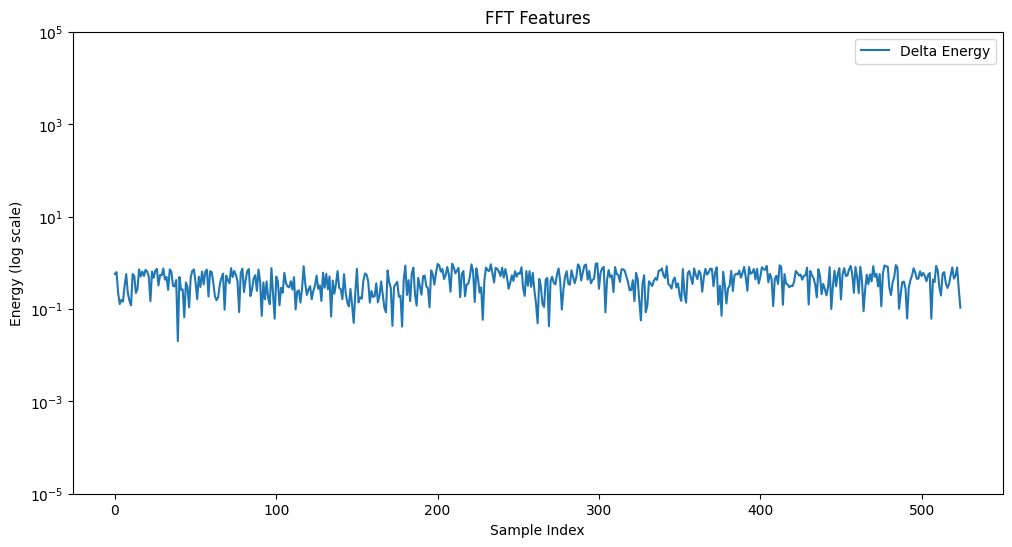

In [45]:
import matplotlib.pyplot as plt

# Plot FFT features
plt.figure(figsize=(12, 6))
#plt.plot(df.index, df['E_alpha'], label='Alpha Energy')
#plt.plot(df.index, df['E_beta'], label='Beta Energy')
#plt.plot(df.index, df['E_theta'], label='Theta Energy')
plt.plot(df.index, df['E_delta'], label='Delta Energy')
#plt.plot(df.index, df['alpha_beta_ratio'], label='Alpha/Beta Ratio')

plt.yscale('log')

threshold = 1e5
plt.ylim([1e-5, threshold])

plt.xlabel('Sample Index')
plt.ylabel('Energy (log scale)')
plt.title('FFT Features')
plt.legend()
plt.show()


In [46]:
X_train, X_test, y_train, y_test = train_test_split(df_scaled.drop('label', axis=1), df_scaled['label'], test_size=0.2, random_state=42)

#clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = SVC(probability=True, random_state=42)


clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Classification Accuracy: {accuracy}")

Classification Accuracy: 0.819047619047619


In [ ]:
# DIAGNOSTIC: Check data quality before training
print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Check class balance
print("\nClass distribution:")
class_counts = df_scaled.groupby('label').size()
print(class_counts)
print(f"\nBalance ratio (min/max): {class_counts.min() / class_counts.max():.2f}")
if class_counts.min() / class_counts.max() < 0.5:
    print("⚠️  WARNING: Severe class imbalance detected!")

# Check if classes are separable
print("\n" + "=" * 70)
print("FEATURE SEPARABILITY TEST")
print("=" * 70)
from scipy.stats import f_oneway

# Test key features
key_features = ['E_alpha', 'E_beta', 'alpha_beta_ratio', 'hjorth_mobility', 'signal_variance']
print("\nF-statistic for key features (higher = more separable):")
for feat in key_features:
    vals = [df_scaled[df_scaled['label'] == i][feat].values for i in range(4)]
    f_stat, p_val = f_oneway(*vals)
    print(f"  {feat:25s} F={f_stat:6.2f} p={p_val:.6f}")

# OPTIMAL TRAINING - GridSearchCV with class_weight='balanced'
print("\n" + "=" * 70)
print("TRAINING 4-CLASS SVM")
print("=" * 70)

import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import time

X = df_scaled.drop('label', axis=1)
y = df_scaled['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature count: {X_train.shape[1]}")

# Check test set class distribution
print("\nTest set class distribution:")
test_counts = pd.Series(y_test).value_counts().sort_index()
print(test_counts)

# GridSearch for best hyperparameters with class_weight='balanced'
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'poly']
}

print(f"\nRunning GridSearchCV (testing {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])} combinations)...")
print("This will take 1-2 minutes...")

start_time = time.time()
grid_search = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring='f1_macro',  # Use macro F1 for balanced multi-class
    verbose=1
)
grid_search.fit(X_train, y_train)
train_time = time.time() - start_time

model = grid_search.best_estimator_
test_accuracy = model.score(X_test, y_test)

print("\n" + "=" * 70)
print("TRAINING RESULTS")
print("=" * 70)
print(f"Training time: {train_time:.1f}s")
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")
print(f"Test set accuracy: {test_accuracy:.4f} ({test_accuracy*100:.1f}%)")

# Show confusion matrix for test set
from sklearn.metrics import confusion_matrix
y_pred_test = model.predict(X_test)
conf_test = confusion_matrix(y_test, y_pred_test)
print("\nTest Set Confusion Matrix:")
print("       Rest  Focus  Left  Right")
for i, row in enumerate(conf_test):
    class_name = ['Rest ', 'Focus', 'Left ', 'Right'][i]
    print(f'{class_name}: {row}')

print("=" * 70)

In [ ]:
# Feature Analysis - Understanding what drives the 4-class classification
print("=" * 70)
print("FEATURE ANALYSIS (4-CLASS)")
print("=" * 70)

# Compare feature distributions by class
print("\nFeature Means by Class:")
print("-" * 70)
feature_comparison = df.groupby('label')[columns].mean()
feature_comparison.index = ['Relax/Down (0)', 'Focus/Up (1)', 'Pulse Left Fist (2)', 'Clench Right Fist (3)']
print(feature_comparison.T)

print("\n" + "=" * 70)
print("FEATURE DISCRIMINATIVE POWER (ANOVA F-statistic)")
print("=" * 70)
from scipy import stats

f_values = []
for col in columns:
    class_vals = [df[df['label'] == i][col].values for i in range(4)]
    f_stat, p_val = stats.f_oneway(*class_vals)
    f_values.append((col, p_val, f_stat))

# Sort by F-statistic (higher = more discriminative across all classes)
f_values.sort(key=lambda x: x[2], reverse=True)

print("\nMost discriminative features (p < 0.05 = significant):")
for feat, pval, fstat in f_values[:10]:
    significance = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
    print(f"  {feat:25s} F={fstat:8.2f} p={pval:.6f} {significance}")

print("\n" + "=" * 70)

In [49]:
import pickle
import os

# Save to python_solution folder (works in both Colab and local)
model_path = '../python_solution/model.pkl'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(model_path), exist_ok=True)

with open(model_path, 'wb') as file:
    pickle.dump(model, file)

print(f"✓ Model saved to {os.path.abspath(model_path)}")

# If running in Colab, also download the file
try:
    from google.colab import files
    files.download(model_path)
    print(f"✓ Downloaded to your local Downloads folder")
except ImportError:
    # Not in Colab, file is already in the right place
    print(f"✓ Ready to use with predict.py")

✓ Model saved to /Users/sorin/Documents/Repos/BCI/python_solution/model.pkl
✓ Ready to use with predict.py


In [50]:
import pickle
import os

# Save to python_solution folder (works in both Colab and local)
scaler_path = '../python_solution/scaler.pkl'

# Create directory if it doesn't exist
os.makedirs(os.path.dirname(scaler_path), exist_ok=True)

with open(scaler_path, 'wb') as file:
    pickle.dump(scaler, file)

print(f"✓ Scaler saved to {os.path.abspath(scaler_path)}")

# If running in Colab, also download the file
try:
    from google.colab import files
    files.download(scaler_path)
    print(f"✓ Downloaded to your local Downloads folder")
    print("\n" + "="*70)
    print("📁 Move downloaded files from ~/Downloads/ to python_solution/:")
    print("   mv ~/Downloads/model.pkl python_solution/")
    print("   mv ~/Downloads/scaler.pkl python_solution/")
    print("="*70)
except ImportError:
    # Not in Colab, file is already in the right place
    print(f"✓ Ready to use with predict.py")

✓ Scaler saved to /Users/sorin/Documents/Repos/BCI/python_solution/scaler.pkl
✓ Ready to use with predict.py


In [51]:
probabilities = model.predict_proba(X_test)[:,1]
print(f"Class Probabilities: {probabilities}")

Class Probabilities: [0.9519279  0.43273968 0.7369219  0.39751537 0.72837343 0.90681645
 0.64979211 0.95325186 0.26761106 0.07467783 0.04174662 0.98772043
 0.05227501 0.73665442 0.98583142 0.10991677 0.46367541 0.17966546
 0.29896682 0.07500878 0.82005085 0.95067295 0.93901566 0.95011583
 0.88724675 0.37364801 0.04476789 0.69978827 0.99268124 0.95858232
 0.68232963 0.39540965 0.84183055 0.99181235 0.14280105 0.85828921
 0.92820272 0.1693178  0.1713973  0.14902567 0.01719426 0.05476336
 0.62669719 0.23401977 0.92413485 0.86750906 0.66292939 0.06196274
 0.93182906 0.1446672  0.16819006 0.07533165 0.91290419 0.79280783
 0.33287762 0.19495744 0.05356102 0.14847581 0.81190595 0.95340041
 0.84317927 0.80603956 0.92603744 0.12139696 0.45120097 0.98743138
 0.66934023 0.5        0.31146907 0.87573283 0.11943934 0.60861031
 0.05560688 0.23458118 0.0135725  0.3322788  0.95230685 0.01126599
 0.01215098 0.22003323 0.13909357 0.66502401 0.03293141 0.70135758
 0.15572994 0.99243715 0.10075979 0.04689

In [ ]:
# REMOVED: Calibration curve only works for binary classification
# For 4-class problems, individual class probabilities can be checked in the classification report

print("Calibration curve skipped (not applicable for multi-class)")

In [53]:
# REMOVED: Calibration reduces accuracy from 0.77 to 0.75 and adds processing time
# Keeping the original model performs better
# from sklearn.calibration import CalibratedClassifierCV
# calibrator = CalibratedClassifierCV(model, cv=3)
# calibrator.fit(X_train,y_train)
# yhat = calibrator.predict(X_test)

In [54]:
# REMOVED: Calibration curve - not needed for production model
# from sklearn.calibration import calibration_curve
# fop, mpv = calibration_curve(y_test, yhat, n_bins=10)
# plt.plot([0, 1], [0, 1], linestyle='--')
# plt.plot(mpv, fop, marker='.')
# plt.show()

In [55]:
# Using original model predictions (better accuracy than calibrated)
y_pred_test = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_test)
print(f"Classification Accuracy: {accuracy:.4f}")

Classification Accuracy: 0.8476


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

y_true = df_scaled['label']
y_pred = model.predict(X_scaled)

# Overall accuracy
accuracy = accuracy_score(y_true, y_pred)
print(f'Overall Accuracy: {accuracy:.4f}')
print(f'Overall Accuracy: {accuracy*100:.1f}%')

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
print('\nConfusion Matrix:')
print('Rows = True label, Cols = Predicted label')
print('         Down  Up    Left  Right')
for i, row in enumerate(conf_matrix):
    class_name = ['Down ', 'Up   ', 'Left ', 'Right'][i]
    print(f'{class_name}: {row}')

# Per-class accuracy
print('\nPer-Class Accuracy:')
for i in range(4):
    class_name = ['Relax/Down (0)', 'Focus/Up (1)', 'Left (2)', 'Right (3)'][i]
    class_acc = conf_matrix[i, i] / conf_matrix[i, :].sum()
    print(f'  {class_name}: {class_acc:.1%}')

# Detailed Classification Report
print('\nDetailed Classification Report:')
target_names = ['Relax/Down (0)', 'Focus/Up (1)', 'Left (2)', 'Right (3)']
class_report = classification_report(y_true, y_pred, target_names=target_names)
print(class_report)

# Check class distribution
print('\nClass Distribution in Training Data:')
for i in range(4):
    count = np.sum(y_true == i)
    pct = count / len(y_true) * 100
    class_name = ['Down', 'Up', 'Left', 'Right'][i]
    print(f'  {class_name}: {count} samples ({pct:.1f}%)')